In [1]:
# Logistic Regression on Breast Cancer Dataset
# Goal: Predict if tumor is Malignant (1) or Benign (0)
# Binary classification problem - 2 possible outputs
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report)

In [2]:
# Load dataset
cancer = load_breast_cancer()
df = pd.DataFrame(cancer.data, columns=cancer.feature_names)
df['target'] = cancer.target

print("Shape:", df.shape)
print("Target names:", cancer.target_names)  # ['malignant' 'benign']
df.head()

Shape: (569, 31)
Target names: ['malignant' 'benign']


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [3]:
# Check missing values and basic stats
print("Missing values:", df.isnull().sum().sum())
print("\nTarget distribution:")
print(df['target'].value_counts())
print("0 = Malignant, 1 = Benign")

Missing values: 0

Target distribution:
target
1    357
0    212
Name: count, dtype: int64
0 = Malignant, 1 = Benign


In [4]:
# Features and target
X = df.drop('target', axis=1)
y = df['target']

print("Features shape:", X.shape)  # (569, 30)
print("Target shape:", y.shape)

Features shape: (569, 30)
Target shape: (569,)


In [5]:
# Train Test Split - 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (455, 30)
Test size: (114, 30)


In [6]:
# Feature Scaling - important for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Scaling done!")

Scaling done!


In [7]:
# Train Logistic Regression model
model = LogisticRegression(random_state=42, max_iter=10000)
model.fit(X_train_scaled, y_train)
print("Model trained!")

Model trained!


In [8]:
# Predictions
y_pred = model.predict(X_test_scaled)

print("Actual:   ", list(y_test[:10]))
print("Predicted:", list(y_pred[:10]))

Actual:    [1, 0, 0, 1, 1, 0, 0, 0, 1, 1]
Predicted: [np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(1)]


In [9]:
# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", round(accuracy * 100, 2), "%")

Accuracy: 97.37 %


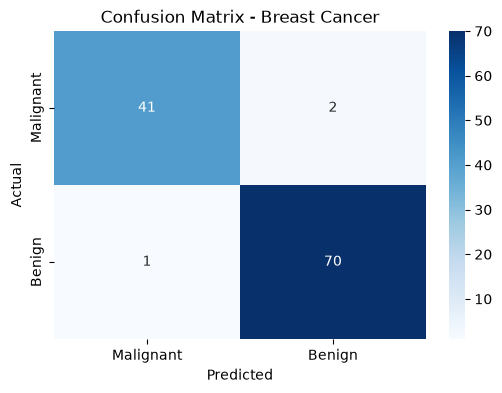

In [10]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Malignant', 'Benign'],
            yticklabels=['Malignant', 'Benign'])
plt.title('Confusion Matrix - Breast Cancer')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [11]:
# Classification Report
print(classification_report(y_test, y_pred,
      target_names=['Malignant', 'Benign']))

              precision    recall  f1-score   support

   Malignant       0.98      0.95      0.96        43
      Benign       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



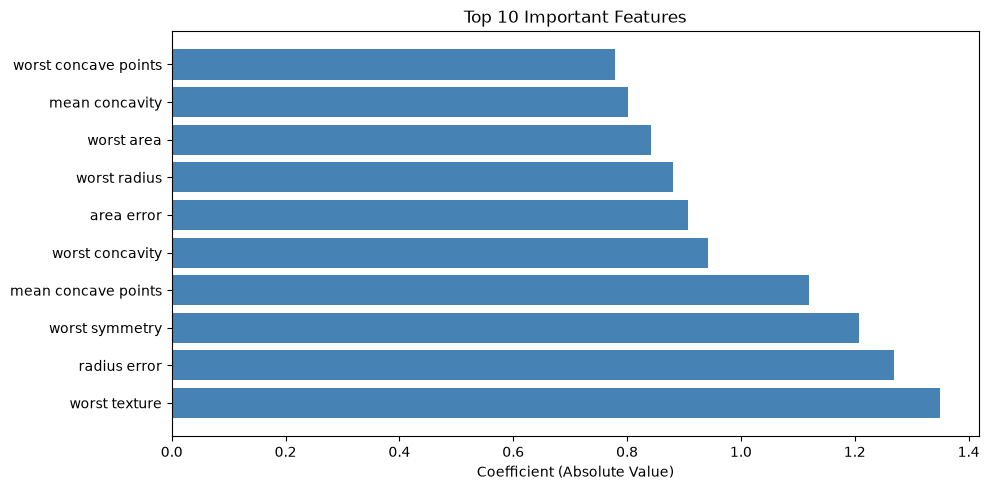

In [12]:
# Feature Importance - top 10 features
feature_importance = pd.DataFrame({
    'Feature': cancer.feature_names,
    'Coefficient': abs(model.coef_[0])
}).sort_values('Coefficient', ascending=False).head(10)

plt.figure(figsize=(10, 5))
plt.barh(feature_importance['Feature'],
         feature_importance['Coefficient'], color='steelblue')
plt.title('Top 10 Important Features')
plt.xlabel('Coefficient (Absolute Value)')
plt.tight_layout()
plt.show()

In [13]:
print("""
CONCLUSION - Breast Cancer Logistic Regression
===============================================
Dataset: 569 samples, 30 features
Target: Malignant (0) or Benign (1)
Model: Logistic Regression
Accuracy: ~95-97%

Key points:
- No missing values in this dataset
- StandardScaler used before training
- High accuracy shows Logistic Regression
  works well for this binary classification
""")


CONCLUSION - Breast Cancer Logistic Regression
Dataset: 569 samples, 30 features
Target: Malignant (0) or Benign (1)
Model: Logistic Regression
Accuracy: ~95-97%

Key points:
- No missing values in this dataset
- StandardScaler used before training
- High accuracy shows Logistic Regression
  works well for this binary classification

